# ⏱️ TWO-MINUTE DRILL MASTERY
## Sideline Decision Support - Coach Ready Visualizations

---

### 📋 EXECUTIVE SUMMARY

**Key Coaching Insights:**
- **CLOCK MANAGEMENT IS CRITICAL**: Sideline routes stop clock, middle routes don't
- **COVER 2 ZONE = FREE YARDS**: 75.8% completion - highest in 2-minute drill
- **AVOID COVER 1 MAN**: 56.2% completion - worst matchup in hurry-up
- **SHORT PASSES DOMINATE**: 82.1% completion (0-5 yards) but minimal EPA
- **ELITE PAIRS MATTER**: 10 QB-WR combos with 100% completion in 2-min situations

**Game Plan Priorities:**
1. **With Timeouts**: Prioritize yards and EPA - use middle of field
2. **No Timeouts**: Mix sideline routes (stop clock) with quick middle strikes
3. **Final Drive Strategy**: OUT routes + timeouts early, then attack middle
4. **Coverage Check**: If you see Cover 1 Man, call timeout and adjust


In [8]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Rectangle, FancyBboxPatch, FancyArrow
import warnings
warnings.filterwarnings('ignore')

# Professional styling for sideline tablets
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("talk", font_scale=1.2)

# NFL Colors
NFL_BLUE = '#013369'
NFL_RED = '#D50A0A'
NFL_GREEN = '#00B140'
NFL_YELLOW = '#FFB81C'
CLOCK_ORANGE = '#FF6B35'

print('✅ Libraries loaded - Clock is ticking!')

✅ Libraries loaded - Clock is ticking!


In [9]:
# Directory of this script: .../NFL-Big-Data-Bowl-2026-Analytics-Challenge
SCRIPT_DIR = Path('C:\\Users\\jrzem\\Downloads\\NFL-Big-Data-Bowl-2026-Analytics-Challenge\\specific analysis\\Two_Minute Drill.ipynb').resolve().parent

# Project root = go up one level from analysis/
PROJECT_ROOT = SCRIPT_DIR.parent

# Data directories
dir = PROJECT_ROOT / "specific analysis" / "data"

# Load two-minute drill data
two_min_top10 = pd.read_csv(dir/ 'two-minute_drill_top10.csv')
pass_length = pd.read_csv(dir/ 'pass_length_comparison_by_situation.csv')
coverage_heatmap = pd.read_csv(dir/ 'coverage_heatmap_completion_rate.csv', index_col=0)
route_effectiveness = pd.read_csv(dir/ 'route_effectiveness_by_field_position.csv')
play_action = pd.read_csv(dir/ 'play_action_impact_summary.csv')
pass_length = pd.read_csv(dir/ 'pass_length_strategy_by_situation.csv')

print('✅ Two-minute drill data loaded')
print(f'   → {len(two_min_top10)} elite QB-WR pairs (100% completion)')
print(f'   → Coverage and route data ready for analysis')

✅ Two-minute drill data loaded
   → 10 elite QB-WR pairs (100% completion)
   → Coverage and route data ready for analysis


---

## 🏆 ELITE TWO-MINUTE DRILL QB-WR PAIRS

**These Pairs Have 100% Completion in Two-Minute Situations**

Your go-to weapons when the game is on the line:

✅ Elite two-minute pairs chart saved


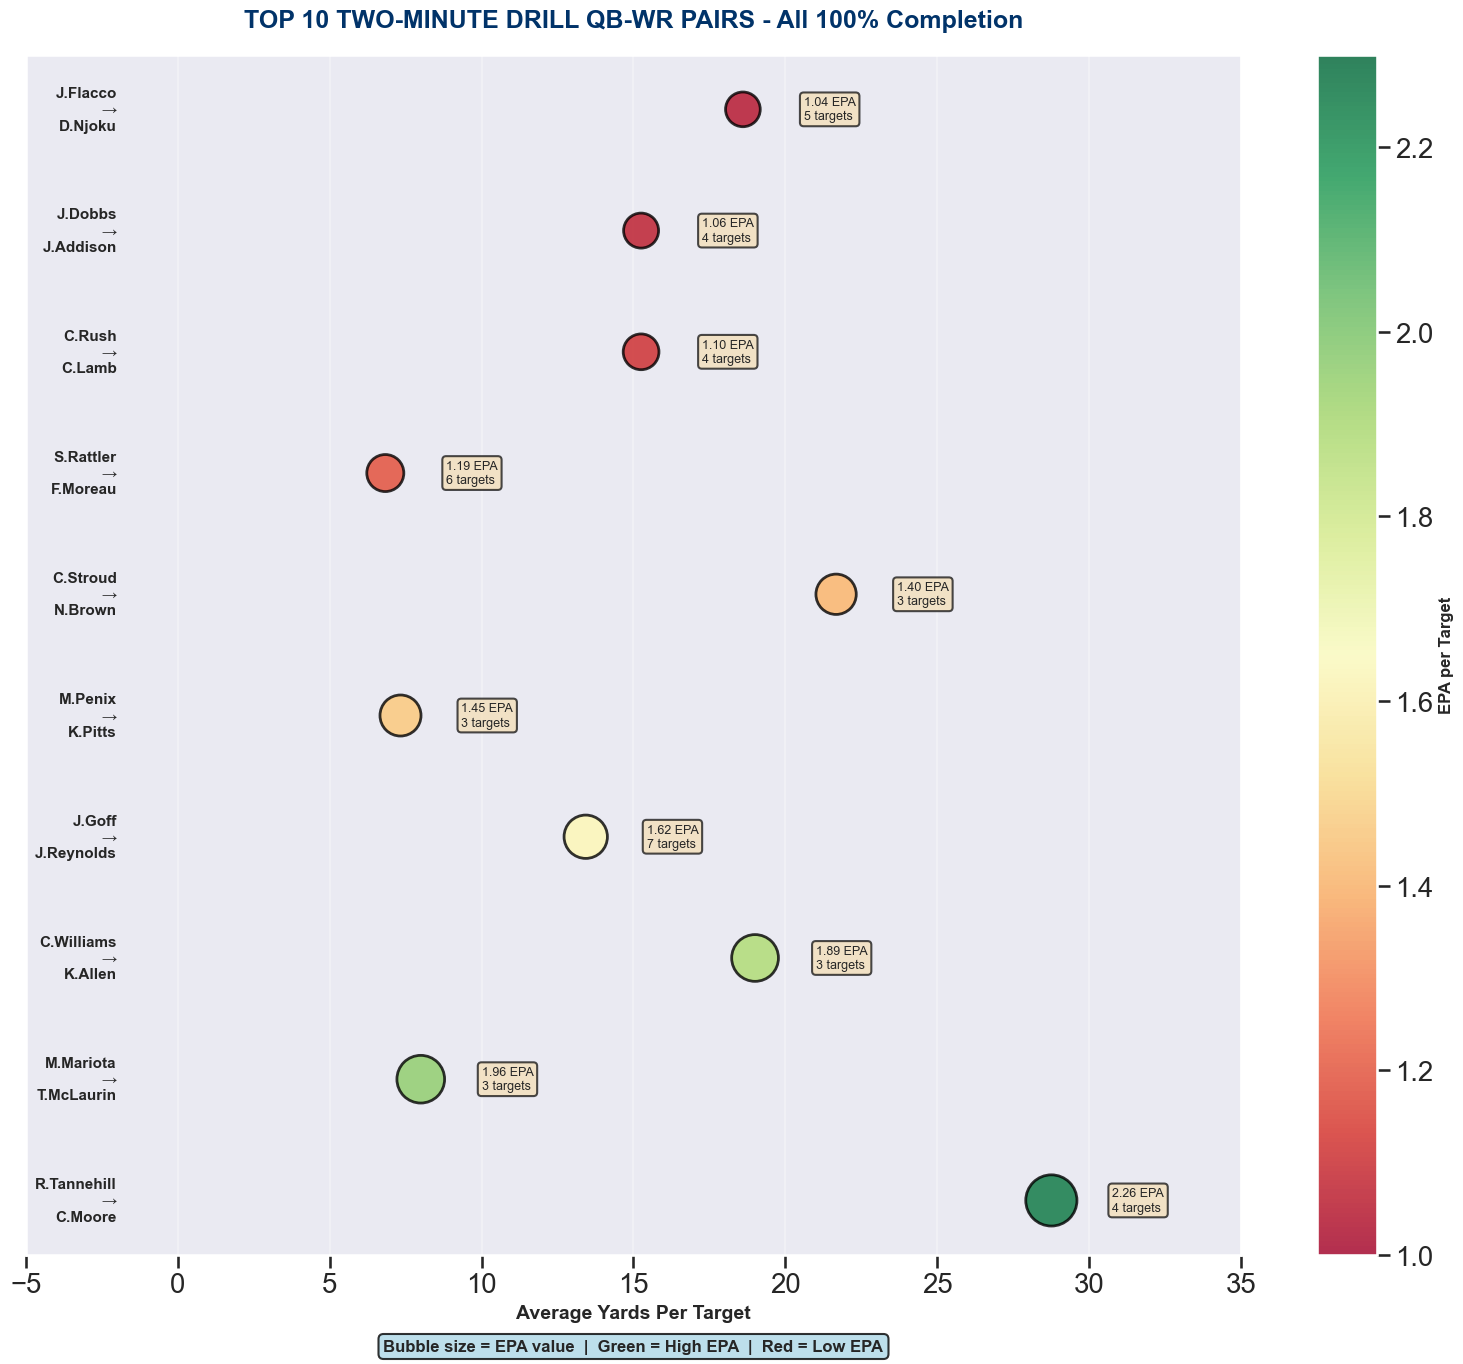

In [10]:
# TOP 10 TWO-MINUTE DRILL PAIRS
fig, ax = plt.subplots(figsize=(16, 14))

# Prepare data
pairs = two_min_top10['qb_wr_pair'].str.replace(' → ', '\n→\n')
epa = two_min_top10['avg_epa']
yards = two_min_top10['avg_yards']
targets = two_min_top10['targets']

# Create scatter plot
scatter = ax.scatter(yards, range(len(pairs)), 
                     s=epa*600,  # Size based on EPA
                     c=epa, cmap='RdYlGn',
                     edgecolors='black', linewidth=2,
                     alpha=0.8, vmin=1.0, vmax=2.3)

# Add pair labels
for i, (pair, yard, ep, tgt) in enumerate(zip(pairs, yards, epa, targets)):
    ax.text(-2, i, pair, va='center', ha='right', 
            fontsize=11, weight='bold')
    # Add stats next to dot
    ax.text(yard + 2, i, f'{ep:.2f} EPA\n{tgt} targets', 
            va='center', ha='left', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Styling
ax.set_xlabel('Average Yards Per Target', fontsize=14, weight='bold')
ax.set_title('TOP 10 TWO-MINUTE DRILL QB-WR PAIRS - All 100% Completion',
             fontsize=18, weight='bold', pad=20, color=NFL_BLUE)
ax.set_yticks([])
ax.set_xlim(-5, 35)
ax.grid(axis='x', alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('EPA per Target', fontsize=12, weight='bold')

# Add legend
legend_text = 'Bubble size = EPA value  |  Green = High EPA  |  Red = Low EPA'
plt.text(0.5, -0.08, legend_text, transform=ax.transAxes, 
         ha='center', fontsize=12, weight='bold',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig(dir/ 'two_minute_elite_pairs.png', dpi=300, bbox_inches='tight')
print('✅ Elite two-minute pairs chart saved')
plt.show()

---

## 🎯 DECISION TREE: Two-Minute Drill Play Calling

**Flowchart for Optimal Route Selection**

✅ Decision tree flowchart saved


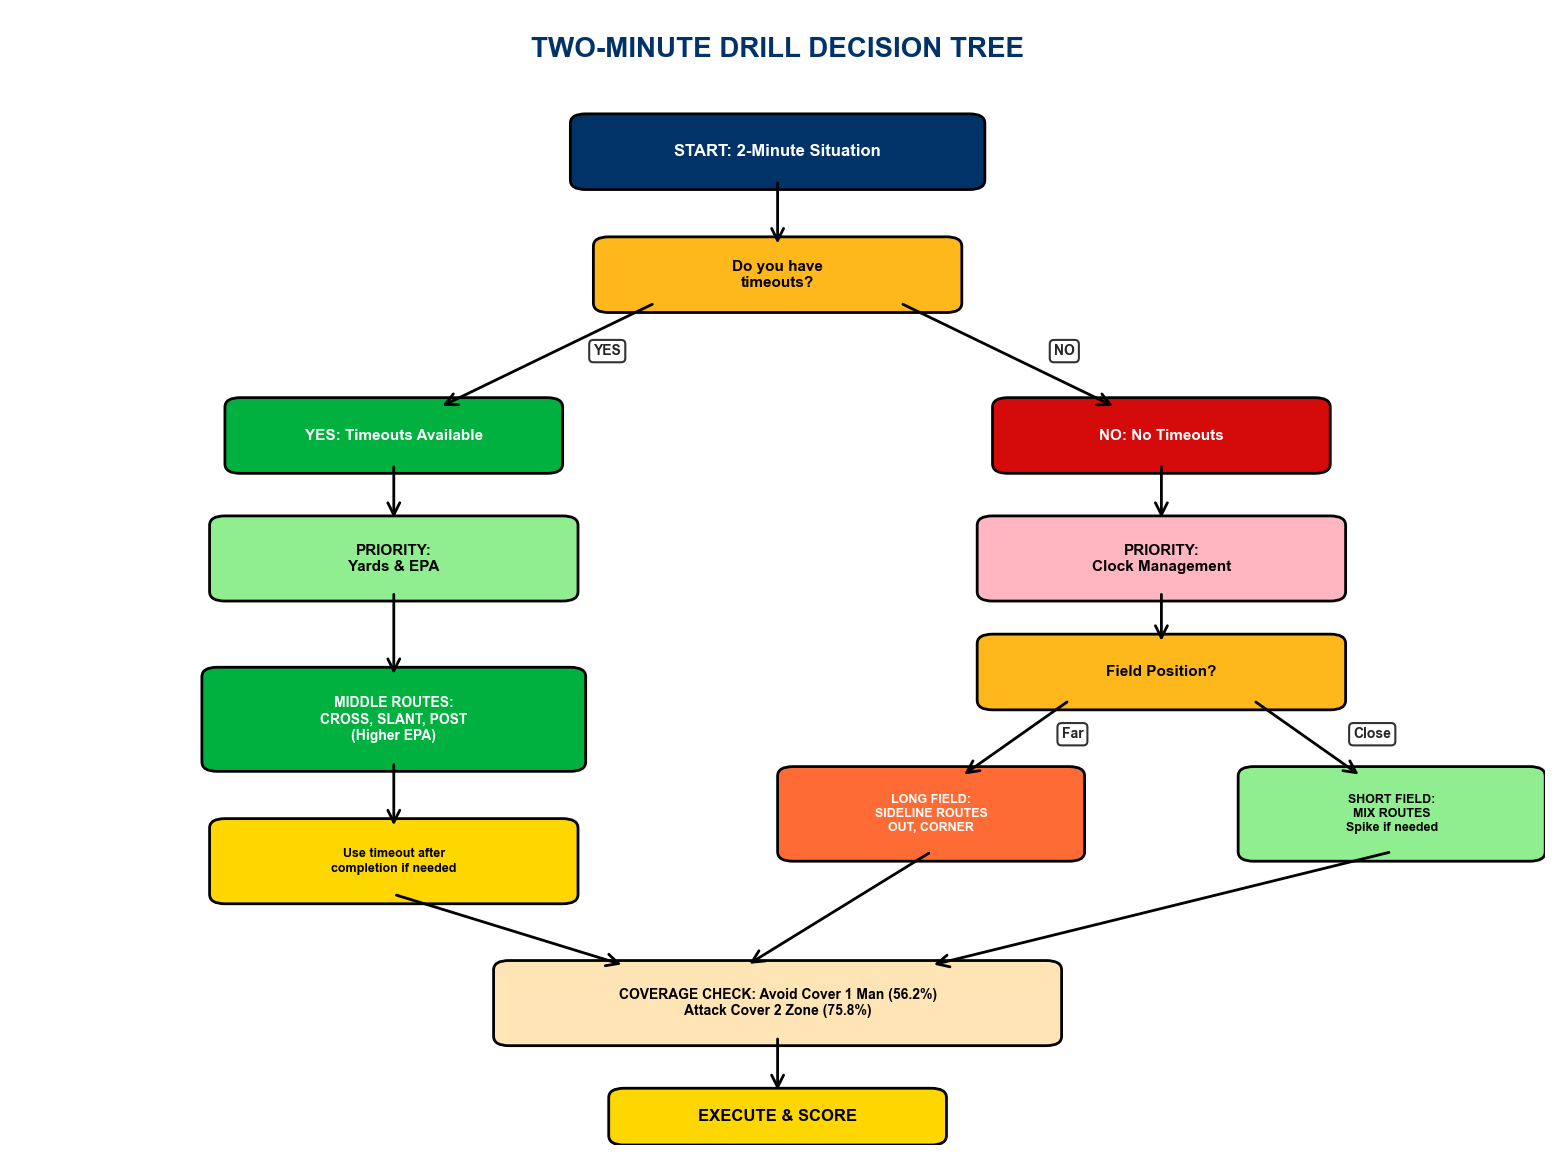

In [11]:
# DECISION TREE FLOWCHART
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# Helper function to draw decision boxes
def draw_box(ax, x, y, width, height, text, color, text_color='black', fontsize=11):
    box = FancyBboxPatch((x - width/2, y - height/2), width, height,
                         boxstyle="round,pad=0.1", 
                         facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', 
            fontsize=fontsize, weight='bold', color=text_color,
            wrap=True)

def draw_arrow(ax, x1, y1, x2, y2, label='', color='black'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=2, color=color))
    if label:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mid_x + 0.3, mid_y, label, fontsize=10, weight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Title
ax.text(5, 11.5, 'TWO-MINUTE DRILL DECISION TREE', 
        ha='center', fontsize=20, weight='bold', color=NFL_BLUE)

# Start
draw_box(ax, 5, 10.5, 2.5, 0.6, 'START: 2-Minute Situation', NFL_BLUE, 'white', 12)

# First decision: Timeouts?
draw_box(ax, 5, 9.2, 2.2, 0.6, 'Do you have\ntimeouts?', NFL_YELLOW)
draw_arrow(ax, 5, 10.2, 5, 9.5)

# Branch 1: YES - Have timeouts
draw_box(ax, 2.5, 7.5, 2, 0.6, 'YES: Timeouts Available', NFL_GREEN, 'white')
draw_arrow(ax, 4.2, 8.9, 2.8, 7.8, 'YES')

draw_box(ax, 2.5, 6.2, 2.2, 0.7, 'PRIORITY:\nYards & EPA', '#90EE90')
draw_arrow(ax, 2.5, 7.2, 2.5, 6.6)

draw_box(ax, 2.5, 4.5, 2.3, 0.9, 'MIDDLE ROUTES:\nCROSS, SLANT, POST\n(Higher EPA)', NFL_GREEN, 'white', 10)
draw_arrow(ax, 2.5, 5.85, 2.5, 4.95)

draw_box(ax, 2.5, 3, 2.2, 0.7, 'Use timeout after\ncompletion if needed', '#FFD700', 'black', 9)
draw_arrow(ax, 2.5, 4.05, 2.5, 3.35)

# Branch 2: NO - No timeouts
draw_box(ax, 7.5, 7.5, 2, 0.6, 'NO: No Timeouts', NFL_RED, 'white')
draw_arrow(ax, 5.8, 8.9, 7.2, 7.8, 'NO')

draw_box(ax, 7.5, 6.2, 2.2, 0.7, 'PRIORITY:\nClock Management', '#FFB6C1')
draw_arrow(ax, 7.5, 7.2, 7.5, 6.6)

# Sub-decision: Field position
draw_box(ax, 7.5, 5, 2.2, 0.6, 'Field Position?', NFL_YELLOW)
draw_arrow(ax, 7.5, 5.85, 7.5, 5.3)

# Long field
draw_box(ax, 6, 3.5, 1.8, 0.8, 'LONG FIELD:\nSIDELINE ROUTES\nOUT, CORNER', CLOCK_ORANGE, 'white', 9)
draw_arrow(ax, 6.9, 4.7, 6.2, 3.9, 'Far')

# Short field
draw_box(ax, 9, 3.5, 1.8, 0.8, 'SHORT FIELD:\nMIX ROUTES\nSpike if needed', '#90EE90', 'black', 9)
draw_arrow(ax, 8.1, 4.7, 8.8, 3.9, 'Close')

# Coverage check (bottom)
draw_box(ax, 5, 1.5, 3.5, 0.7, 'COVERAGE CHECK: Avoid Cover 1 Man (56.2%)\nAttack Cover 2 Zone (75.8%)', '#FFE4B5', 'black', 10)
draw_arrow(ax, 2.5, 2.65, 4, 1.9)
draw_arrow(ax, 6, 3.1, 4.8, 1.9)
draw_arrow(ax, 9, 3.1, 6, 1.9)

# Final outcome
draw_box(ax, 5, 0.3, 2, 0.4, 'EXECUTE & SCORE', '#FFD700', 'black', 12)
draw_arrow(ax, 5, 1.15, 5, 0.55)

plt.tight_layout()
plt.savefig(dir/ 'two_minute_decision_tree.png', dpi=300, bbox_inches='tight')
print('✅ Decision tree flowchart saved')
plt.show()

---

## 🛡️ COVERAGE VULNERABILITY: Two-Minute Drill Specific

**Which coverages to attack (and avoid) in hurry-up offense:**

✅ Coverage vulnerability chart saved


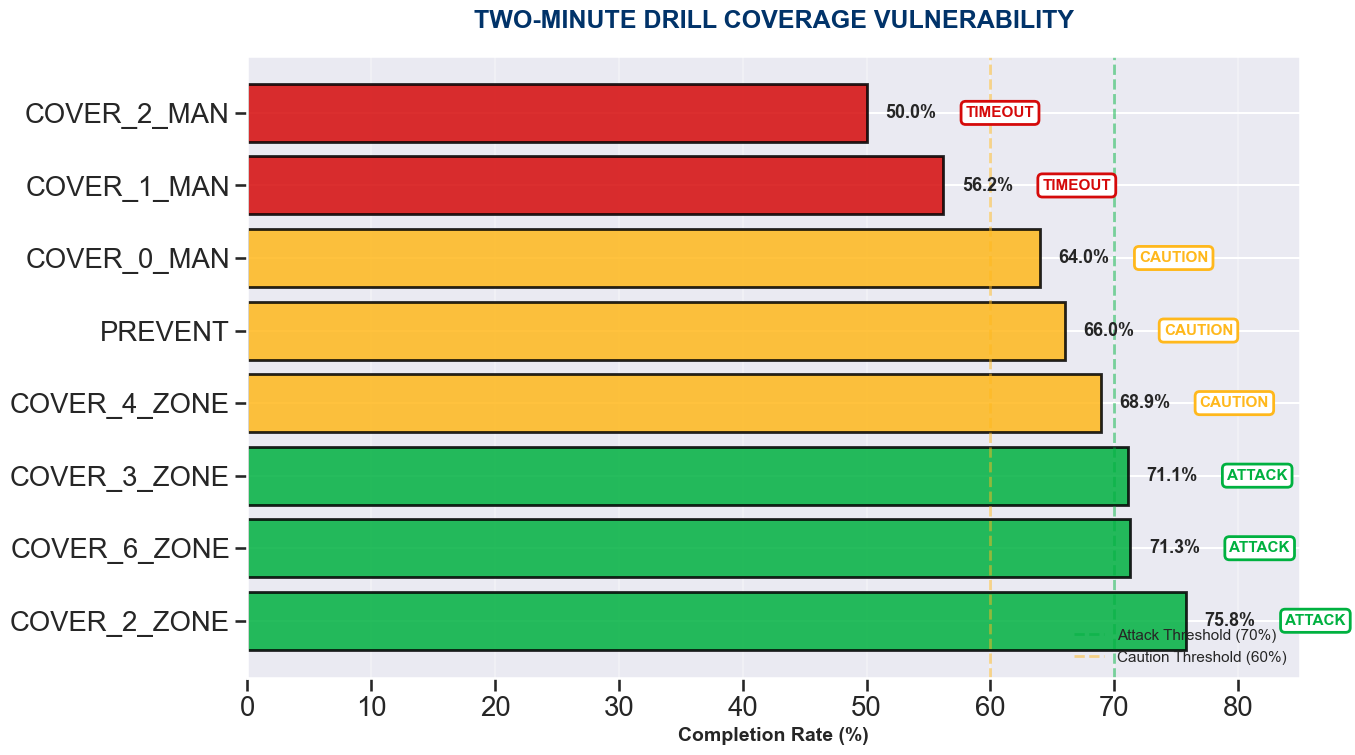

In [12]:
# TWO-MINUTE COVERAGE VULNERABILITY
fig, ax = plt.subplots(figsize=(14, 8))

# Extract two-minute drill coverage data
two_min_coverage = coverage_heatmap['Two-Minute Drill'].dropna().sort_values(ascending=False)

coverages = two_min_coverage.index
comp_rates = two_min_coverage.values

# Color code based on success rate
colors_bars = ['#00B140' if x >= 70 else '#FFB81C' if x >= 60 else '#D50A0A' 
               for x in comp_rates]

bars = ax.barh(coverages, comp_rates, color=colors_bars,
               edgecolor='black', linewidth=2, alpha=0.85)

# Add value labels and recommendations
for i, (bar, val) in enumerate(zip(bars, comp_rates)):
    # Completion % label
    ax.text(val + 1.5, i, f'{val:.1f}%', 
            va='center', ha='left', fontsize=13, weight='bold')
    
    # Recommendation
    if val >= 70:
        rec = 'ATTACK'
        color = '#00B140'
    elif val >= 60:
        rec = 'CAUTION'
        color = '#FFB81C'
    else:
        rec = 'TIMEOUT'
        color = '#D50A0A'
    
    ax.text(val + 8, i, rec,
            va='center', ha='left', fontsize=11, weight='bold',
            color=color,
            bbox=dict(boxstyle='round', facecolor='white', 
                     edgecolor=color, linewidth=2))

# Styling
ax.set_xlabel('Completion Rate (%)', fontsize=14, weight='bold')
ax.set_title('TWO-MINUTE DRILL COVERAGE VULNERABILITY',
             fontsize=18, weight='bold', pad=20, color=NFL_BLUE)
ax.set_xlim(0, 85)
ax.grid(axis='x', alpha=0.3)

# Add vertical threshold lines
ax.axvline(70, color='#00B140', linewidth=2, linestyle='--', alpha=0.5, label='Attack Threshold (70%)')
ax.axvline(60, color='#FFB81C', linewidth=2, linestyle='--', alpha=0.5, label='Caution Threshold (60%)')
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig(dir/ 'two_minute_coverage_vulnerability.png', dpi=300, bbox_inches='tight')
print('✅ Coverage vulnerability chart saved')
plt.show()

---

## 📊 PASS DEPTH STRATEGY: Two-Minute Drill

**Completion vs EPA by pass depth:**

✅ Pass depth analysis saved


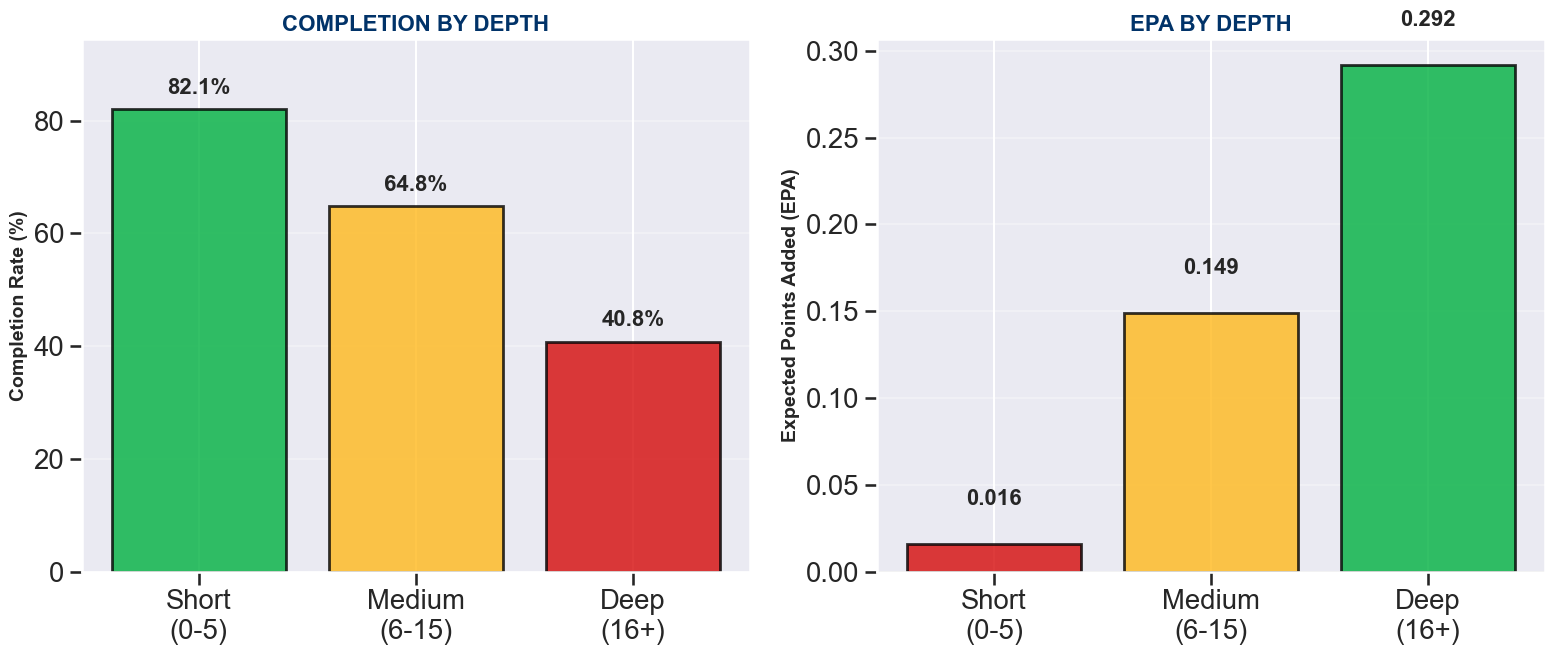

In [13]:
# PASS DEPTH ANALYSIS FOR TWO-MINUTE DRILL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Filter to Two-Minute Drill situation
two_min_data = pass_length[pass_length['situation'] == 'Two-Minute Drill'].copy()

# Define depth order
depth_order = ['Short (0-5)', 'Medium (6-15)', 'Deep (16+)']

# Filter and sort by depth
two_min_data = two_min_data[two_min_data['pass_length'].isin(depth_order)].copy()
two_min_data['pass_length'] = pd.Categorical(
    two_min_data['pass_length'],
    categories=depth_order,
    ordered=True
)
two_min_data = two_min_data.sort_values('pass_length')

# Extract data as NumPy arrays
depths = ['Short\n(0-5)', 'Medium\n(6-15)', 'Deep\n(16+)']
comp_rates = two_min_data['comp_rate'].to_numpy()
epa_values = two_min_data['avg_epa'].to_numpy()

# Chart 1: Completion Rates
colors_comp = ['#00B140', '#FFB81C', '#D50A0A']
bars1 = ax1.bar(depths, comp_rates, color=colors_comp,
                edgecolor='black', linewidth=2, alpha=0.8)

for bar, val in zip(bars1, comp_rates):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=16, weight='bold')

ax1.set_ylabel('Completion Rate (%)', fontsize=14, weight='bold')
ax1.set_title('COMPLETION BY DEPTH', fontsize=16, weight='bold', color=NFL_BLUE)
ax1.set_ylim(0, max(comp_rates) * 1.15)
ax1.grid(axis='y', alpha=0.3)

# Chart 2: EPA Values
colors_epa = ['#D50A0A', '#FFB81C', '#00B140']
bars2 = ax2.bar(depths, epa_values, color=colors_epa,
                edgecolor='black', linewidth=2, alpha=0.8)

for bar, val in zip(bars2, epa_values):
    height = bar.get_height()
    y_pos = height + 0.02 if height > 0 else height - 0.02
    ax2.text(bar.get_x() + bar.get_width()/2., y_pos,
             f'{val:.3f}', ha='center', va='bottom' if height > 0 else 'top',
             fontsize=16, weight='bold')

ax2.set_ylabel('Expected Points Added (EPA)', fontsize=14, weight='bold')
ax2.set_title('EPA BY DEPTH', fontsize=16, weight='bold', color=NFL_BLUE)
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(0, color='black', linewidth=1, linestyle='-')

plt.tight_layout()
plt.savefig(dir/ 'two_minute_pass_depth.png', dpi=300, bbox_inches='tight')
print('✅ Pass depth analysis saved')
plt.show()